In [1]:
import os

# Trick to plot with tex
os.environ["LD_LIBRARY_PATH"] = ""
os.environ["CONDA_PREFIX"] = "/home/guerrini/.conda/envs/sp_validation_3.11"

from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

plt.rc('text', usetex=True)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 60

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"
root_external = "/n09data/guerrini/output_chains/ext_data/"

roots = [
    "SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell",
    "SP_v1.4.6_leak_corr_B_lmin=300_lmax=1600_cell",
    "SP_v1.4.6_leak_corr_C_lmin=300_lmax=1600_cell",
    "SP_v1.4.6_leak_corr_A_10_80",
    "Planck18",
    "DES_Y3",
    "KiDS-1000",
    "KiDS-1000_cosebis",
    "KiDS-1000_bp",
    "DES+KiDS",
    "HSC_Y3",
    "HSC_Y3_cell",
    "SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell",
    "SP_v1.4.6_leak_corr_A_kmax=3Mpc_cell",
    "SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell",
    "SP_v1.4.6_leak_corr_A_include_large_scales_cell",
    "SP_v1.4.6_leak_corr_A_small_scales_cell",
    "SP_v1.4.6_leak_corr_A_large_scales_cell",
    "SP_v1.4.6_leak_corr_A_halofit_cell",
    "SP_v1.4.6_leak_corr_A_HMCode_nobar_cell",
    "SP_v1.4.6_leak_corr_A_OneCov_cell",
    "SP_v1.4.6_A_fid_cell"
]

legend_labels = [
    r"UNIONS $C_\ell$, Blind A (This work)",
    r"UNIONS $C_\ell$, Blind B",
    r"UNIONS $C_\ell$, Blind C",
    r"UNIONS $\xi_\pm(\vartheta)$, (Goh et al., 2026)",
    r"\textit{Planck} 2018",
    r"DES Y3 $\xi_\pm(\vartheta)$",
    r"KiDS-1000 $\xi_\pm(\vartheta)$",
    r"KiDS-1000 $E_n$",
    r"KiDS-1000 $C_E$",
    r"DES Y3 + KiDS-1000 combined",
    r"HSC Y3 $\xi_\pm(\vartheta)$",
    r"HSC Y3 $C_\ell$",
    r"$k_{\rm max}=5h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=2048$",
    r"$k_{\rm max}=3h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=1800$",
    r"$k_{\rm max}=1h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=500$",
    r"Include large scales, $\ell_{\rm max}=1600$",
    r"Small scales only",
    r"Large scales only",
    r"\texttt{Halofit}",
    r"\texttt{HMCode} no baryons",
    r"\texttt{OneCovariance} only",
    r"No leakage correction",
]

colours = [
    "royalblue",
    "crimson",
    "forestgreen",
    "darkorange",
    "violet",
    "black",
    "black",
    "black",
    "black",
    "black",
    "black",
    "black",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
]

categories = [
    "harmonic",
    "harmonic",
    "harmonic",
    "configuration",
    "external",
    "external",
    "external",
    "external_compute_sample",
    "external_compute_sample",
    "external",
    "external",
    "external_compute_sample",
    "harmonic",
    "harmonic",
    "harmonic",
    "harmonic",
    "harmonic",
    "harmonic",
    "harmonic",
    "harmonic",
    "harmonic",
    "harmonic" 
]

print(roots)

['SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell', 'SP_v1.4.6_leak_corr_B_lmin=300_lmax=1600_cell', 'SP_v1.4.6_leak_corr_C_lmin=300_lmax=1600_cell', 'SP_v1.4.6_leak_corr_A_10_80', 'Planck18', 'DES_Y3', 'KiDS-1000', 'KiDS-1000_cosebis', 'KiDS-1000_bp', 'DES+KiDS', 'HSC_Y3', 'HSC_Y3_cell', 'SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell', 'SP_v1.4.6_leak_corr_A_kmax=3Mpc_cell', 'SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell', 'SP_v1.4.6_leak_corr_A_include_large_scales_cell', 'SP_v1.4.6_leak_corr_A_small_scales_cell', 'SP_v1.4.6_leak_corr_A_large_scales_cell', 'SP_v1.4.6_leak_corr_A_halofit_cell', 'SP_v1.4.6_leak_corr_A_HMCode_nobar_cell', 'SP_v1.4.6_leak_corr_A_OneCov_cell', 'SP_v1.4.6_A_fid_cell']


In [2]:
# MAKE PARAMNAMES FILE

for i, root in enumerate(roots):
    category = categories[i]
    if category != "external":
        # Prepare getdist readable files
        root_dir_ = root_dir if category != "external_compute_sample" else root_external
        with open(root_dir_ + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
            params = file.readline()[1:].split('\t')[:-4]
            file.close()
    
        with open(root_dir_ + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
            for i in range(len(params)):
                if len(params[i].split('--')) > 1:
                    file.write(params[i].split('--')[1] + '\n')
                else:
                    file.write(params[i].split('--')[0] + '\n')
            file.close()

In [3]:
#READ CHAIN

chains=[]

for i, root in enumerate(roots):
    category = categories[i]
    if category != "external":
        #Prepare getdist readable files
        root_dir_ = root_dir if category != "external_compute_sample" else root_external
        samples = np.loadtxt(root_dir_ + '{}/samples_{}.txt'.format(root,root))
        print(len(samples))
        if 'nautilus' in root:
            samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
        else:
            samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
        np.savetxt(root_dir_ + '{}/getdist_{}.txt'.format(root,root), samples)
    
    root_dir_ = root_dir if (category not in ["external", "external_compute_sample"]) else root_external
    chain = g.samples_for_root(root_dir_ + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

1420
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell.txt
Removed no burn in
1368
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_B_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_B_lmin=300_lmax=1600_cell.txt
Removed no burn in
1449
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_C_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_C_lmin=300_lmax=1600_cell.txt
Removed no burn in
1618
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_10_80/getdist_SP_v1.4.6_leak_corr_A_10_80.txt
Removed no burn in
16450
/n09data/guerrini/output_chains/ext_data/KiDS-1000_cosebis/getdist_KiDS-1000_cosebis.txt
Removed no burn in
17226
/n09data/guerrini/output_chains/ext_data/KiDS-1000_bp/getdist_KiDS-1000_bp.txt
Removed no burn in
10496
/n09data/guerrini/output_chains/ext_data/HSC_Y3_cell/getdist_HSC_Y3_cell.txt
Removed no burn in
1471
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell/ge

1265
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell/getdist_SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell.txt
Removed no burn in
1686
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_include_large_scales_cell/getdist_SP_v1.4.6_leak_corr_A_include_large_scales_cell.txt
Removed no burn in
1302
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_small_scales_cell/getdist_SP_v1.4.6_leak_corr_A_small_scales_cell.txt
Removed no burn in
1268
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_large_scales_cell/getdist_SP_v1.4.6_leak_corr_A_large_scales_cell.txt
Removed no burn in
1511
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_halofit_cell/getdist_SP_v1.4.6_leak_corr_A_halofit_cell.txt
Removed no burn in
1464


/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_HMCode_nobar_cell/getdist_SP_v1.4.6_leak_corr_A_HMCode_nobar_cell.txt
Removed no burn in
1379
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_OneCov_cell/getdist_SP_v1.4.6_leak_corr_A_OneCov_cell.txt
Removed no burn in
1389
/n09data/guerrini/output_chains/SP_v1.4.6_A_fid_cell/getdist_SP_v1.4.6_A_fid_cell.txt
Removed no burn in


In [4]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','S_8','s_8_input', 'logt_agn','a','m1','bias_1']
label_list = [r'\Omega_{\rm m}', r'\omega_b h^2', r'h_0', r'n_s', r'\sigma_8', r'S_8', r'S_8', r'\log T_{\rm AGN}', r'A_{\rm IA}', r'm_1', r'\Delta z_1']

for i, chain in enumerate(chains):
    print(legend_labels[i])
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        try:
            param_names.parWithName(name).label = label
        except:
            warnings.warn(f"Parameter {name} not found in chain.")

UNIONS $C_\ell$, Blind A (This work)
UNIONS $C_\ell$, Blind B
UNIONS $C_\ell$, Blind C
UNIONS $\xi_\pm(\vartheta)$, (Goh et al., 2026)
\textit{Planck} 2018
DES Y3 $\xi_\pm(\vartheta)$
KiDS-1000 $\xi_\pm(\vartheta)$
KiDS-1000 $E_n$
KiDS-1000 $C_E$
DES Y3 + KiDS-1000 combined
HSC Y3 $\xi_\pm(\vartheta)$
HSC Y3 $C_\ell$
$k_{\rm max}=5h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=2048$
$k_{\rm max}=3h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=1800$
$k_{\rm max}=1h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=500$
Include large scales, $\ell_{\rm max}=1600$
Small scales only
Large scales only
\texttt{Halofit}
\texttt{HMCode} no baryons
\texttt{OneCovariance} only
No leakage correction


/tmp/ipykernel_2767505/639530714.py:11: UserWarning: Parameter OMEGA_M not found in chain.
  warnings.warn(f"Parameter {name} not found in chain.")
/tmp/ipykernel_2767505/639530714.py:11: UserWarning: Parameter ombh2 not found in chain.
  warnings.warn(f"Parameter {name} not found in chain.")
/tmp/ipykernel_2767505/639530714.py:11: UserWarning: Parameter h0 not found in chain.
  warnings.warn(f"Parameter {name} not found in chain.")
/tmp/ipykernel_2767505/639530714.py:11: UserWarning: Parameter n_s not found in chain.
  warnings.warn(f"Parameter {name} not found in chain.")
/tmp/ipykernel_2767505/639530714.py:11: UserWarning: Parameter s_8_input not found in chain.
  warnings.warn(f"Parameter {name} not found in chain.")
/tmp/ipykernel_2767505/639530714.py:11: UserWarning: Parameter logt_agn not found in chain.
  warnings.warn(f"Parameter {name} not found in chain.")
/tmp/ipykernel_2767505/639530714.py:11: UserWarning: Parameter a not found in chain.
  warnings.warn(f"Parameter {name} 

In [5]:
def adjust_paramname_chain(chain, current_name, target_name, label):
    """
    Adjusts the parameter name and label in a GetDist chain.
    """
    param_names = chain.getParamNames()
    par = param_names.parWithName(current_name)

    par.label = label
    par.name = target_name

    chain.setParamNames(param_names)

    p = chain.paramNames.parWithName(target_name)

def derive_parameter_S8(chain):
    """
    Derives the S_8 parameter from Omega_m and Sigma_8 in a GetDist chain.
    S_8 = Sigma_8 * (Omega_m / 0.3) ** 0.5
    """
    omega_m = chain.getParams().OMEGA_M
    sigma_8 = chain.getParams().SIGMA_8

    s_8 = sigma_8 * (omega_m / 0.3) ** 0.5

    chain.addDerived(s_8, name='S_8', label=r'S_8')

    p = chain.paramNames.parWithName('S_8')

    return chain

def derive_parameter_Om(chain):
    """
    Derives the Omega_m parameter from omch2 and h0 in a GetDist chain.
    """
    omch2 = chain.getParams().omch2
    h0 = chain.getParams().h0

    omega_m = omch2 / (h0 / 100) ** 2

    chain.addDerived(omega_m, name='OMEGA_M', label=r'\Omega_{\rm m}')

    
    p = chain.paramNames.parWithName('OMEGA_M')

    return chain

In [6]:
# Micro management of external chains

# Planck 2018 correction of Omega_m label
if 'Planck18' in roots:
    idx = roots.index('Planck18')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')

if 'KiDS-1000' in roots:
    idx = roots.index('KiDS-1000')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')

if 'HSC_Y3' in roots:
    idx = roots.index('HSC_Y3')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')

if 'HSC_Y3_cell' in roots:
    idx = roots.index('HSC_Y3_cell')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')

if 'DES+KiDS' in roots:
    idx = roots.index('DES+KiDS')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')

if 'DES_Y3' in roots:
    idx = roots.index('DES_Y3')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')
    derive_parameter_S8(chains[idx])

In [7]:
param_values = np.array(["# Expt", "Colour", "S8_Mean", "S8_low", "S8_high",  "sigma_8_Mean", "sigma_8_low", "sigma_8_high", "Omega_m_Mean", "Omega_m_low", "Omega_m_high"])
escaped = np.char.replace(legend_labels, '\\', '\\\\')
for i, chain in enumerate(chains):
    print(chain.root)
    margestats = chain.getMargeStats()
    likestats = chain.getLikeStats()

    s8_stats = margestats.parWithName('S_8')
    sigma8_stats = margestats.parWithName('SIGMA_8')
    omegam_stats = margestats.parWithName('OMEGA_M')

    param_values = np.vstack((
        param_values,
        [
            escaped[i],
            colours[i],
            s8_stats.mean,
            s8_stats.mean-s8_stats.limits[0].lower,
            s8_stats.limits[0].upper-s8_stats.mean,
            sigma8_stats.mean,
            sigma8_stats.mean - sigma8_stats.limits[0].lower,
            sigma8_stats.limits[0].upper - sigma8_stats.mean,
            omegam_stats.mean,
            omegam_stats.mean - omegam_stats.limits[0].lower,
            omegam_stats.limits[0].upper - omegam_stats.mean,
        ]
    ))
print(param_values)
np.savetxt(f"{root_dir}/param_values.txt", param_values, fmt=['%s' for i in range(11)], delimiter=';')

/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_B_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_B_lmin=300_lmax=1600_cell
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_C_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_C_lmin=300_lmax=1600_cell
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_10_80/getdist_SP_v1.4.6_leak_corr_A_10_80
/n09data/guerrini/output_chains/ext_data/Planck18/getdist_Planck18


/n09data/guerrini/output_chains/ext_data/DES_Y3/getdist_DES_Y3
/n09data/guerrini/output_chains/ext_data/KiDS-1000/getdist_KiDS-1000
/n09data/guerrini/output_chains/ext_data/KiDS-1000_cosebis/getdist_KiDS-1000_cosebis
/n09data/guerrini/output_chains/ext_data/KiDS-1000_bp/getdist_KiDS-1000_bp
/n09data/guerrini/output_chains/ext_data/DES+KiDS/getdist_DES+KiDS
/n09data/guerrini/output_chains/ext_data/HSC_Y3/getdist_HSC_Y3
/n09data/guerrini/output_chains/ext_data/HSC_Y3_cell/getdist_HSC_Y3_cell
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell/getdist_SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_kmax=3Mpc_cell/getdist_SP_v1.4.6_leak_corr_A_kmax=3Mpc_cell
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell/getdist_SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_include_large_scales_cell/getdist_SP_v1.4.6_leak_corr_A_include_large_scales_cell
/n09data/guerrini/output_ch

In [8]:
# Load the value of the parameters
cosmo = np.loadtxt(f"{root_dir}/param_values.txt",
            dtype={'names': ('Expt', 'colour', 's8_mean', 's8_low', 's8_high', 'sigma8_mean', 'sigma8_low', 'sigma8_high', 'omegam_mean', 'omegam_low', 'omegam_high'),
                   'formats': ('U250', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20')}, skiprows=1, delimiter=';')
expt = np.char.replace(cosmo['Expt'], '\\\\', '\\')
colours =  cosmo['colour']
s8_mean = cosmo['s8_mean'].astype(np.float64)
s8_low = cosmo['s8_low'].astype(np.float64)
s8_high = cosmo['s8_high'].astype(np.float64)
sigma8_mean = cosmo['sigma8_mean'].astype(np.float64)
sigma8_low = cosmo['sigma8_low'].astype(np.float64)
sigma8_high = cosmo['sigma8_high'].astype(np.float64)
omegam_mean = cosmo['omegam_mean'].astype(np.float64)
omegam_low = cosmo['omegam_low'].astype(np.float64)
omegam_high = cosmo['omegam_high'].astype(np.float64)

In [9]:
def get_sigma_tension(mean1, low1, high1, mean2, low2, high2):
    sigma1 = 0.5 * (high1 + low1)
    sigma2 = 0.5 * (high2 + low2)
    delta_mean = np.abs(mean1 - mean2)
    sigma_tension = delta_mean / np.sqrt(sigma1**2 + sigma2**2)
    sign = 1 if mean1 > mean2 else -1
    return sigma_tension * sign

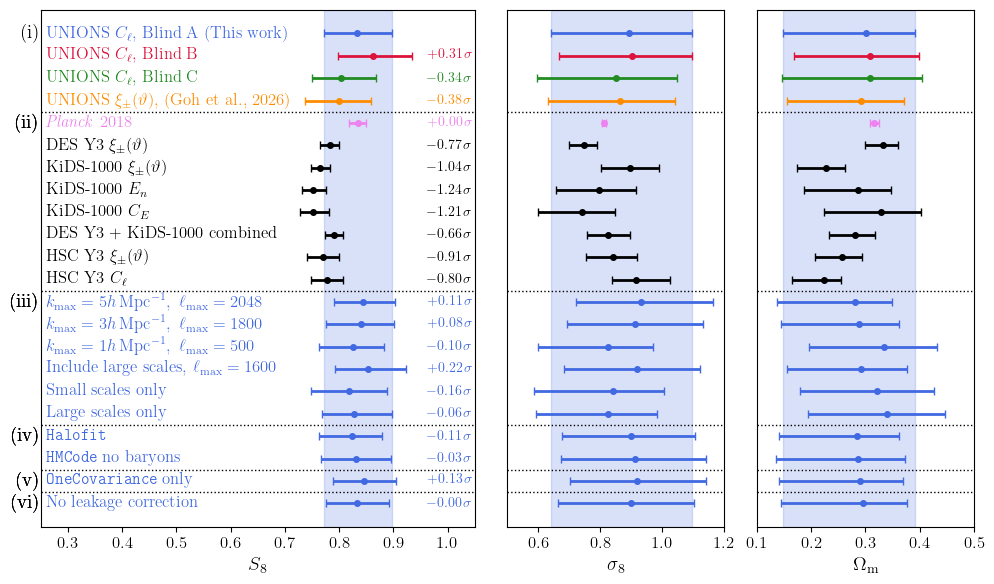

In [11]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 6))
gs = GridSpec(1, 3, width_ratios=[1, 0.5, 0.5])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

axs = [ax1, ax2, ax3]

params = [
    (s8_mean, s8_low, s8_high, r"$S_8$"),
    (sigma8_mean, sigma8_low, sigma8_high, r"$\sigma_8$"),
    (omegam_mean, omegam_low, omegam_high, r"$\Omega_{\rm m}$"),
]
reference = "UNIONS $C_\ell$, Blind A (This work)"
separation_after = [
    r"UNIONS $\xi_\pm(\vartheta)$, (Goh et al., 2026)",
    r"HSC Y3 $C_\ell$",
    r"Large scales only",
    r"\texttt{HMCode} no baryons",
    r"\texttt{OneCovariance} only"
]
list_section_index = [
    r"(ii)",
    r"(iii)",
    r"(iv)",
    r"(v)",
    r"(vi)",
    r"(vii)"
]

preliminary_watermark = False
blind_axes = False
row_spacing = 0.1

index_ref = np.where(expt == reference)[0][0]

y = np.arange(len(expt))
for ax, param in zip(axs, params):
    means, lows, highs, label = param
    for i, mean, low, high, color in zip(y, means, lows, highs, colours):
        ax.errorbar(mean, 0.05+i*row_spacing, xerr=np.array([low, high])[:, None], fmt='o', color=color, ecolor=color, elinewidth=2, capsize=3)
    ax.set_xlabel(label, fontsize=14)
        
    ax.grid(False)
    ax.tick_params(axis='y', left=False, labelleft=False)
    if label == r"$S_8$":
        ax.axvspan(s8_mean[index_ref] - s8_low[index_ref], s8_mean[index_ref] + s8_high[index_ref], color=colours[index_ref], alpha=0.2)
        ax.set_xlim(0.25, 1.05)
        if blind_axes:
            ref_tick = np.mean(s8_mean[:4])
            ax.set_xticks(
                [ref_tick + i*0.1 for i in range(-5, 5)], labels=[]
            )
    elif label == r"$\sigma_8$":
        ax.axvspan(sigma8_mean[index_ref] - sigma8_low[index_ref], sigma8_mean[index_ref] + sigma8_high[index_ref], color=colours[index_ref], alpha=0.2)
        ax.set_xlim(0.5, 1.2)
        if blind_axes:
            ref_tick = np.mean(sigma8_mean[:4])
            ax.set_xticks(
                [ref_tick + i*0.2 for i in range(-2, 2)], labels=[]
            )
    elif label == r"$\Omega_{\rm m}$":
        ax.axvspan(omegam_mean[index_ref] - omegam_low[index_ref], omegam_mean[index_ref] + omegam_high[index_ref], color=colours[index_ref], alpha=0.2)
        ax.set_xlim(0.1, 0.5)
        if blind_axes:
            ref_tick = np.mean(omegam_mean[:4])
            ax.set_xticks(
                [ref_tick + i*0.1 for i in range(-2, 3)], labels=[]
            )


axs[0].set_yticks(0.05+y*row_spacing)
axs[0].set_yticklabels([])
for label, color in zip(expt, colours):
    axs[0].text(0.26, 0.05 + row_spacing * np.where(expt == label)[0][0], label, fontsize=12, ha='left', va='center', color=color)
    if label != reference:
        index = np.where(expt == label)[0][0]
        s8_tension = get_sigma_tension(
            s8_mean[index], s8_low[index], s8_high[index],
            s8_mean[index_ref], s8_low[index_ref], s8_high[index_ref]
        )
        sign_str = "+" if s8_tension > 0 else "-"
        axs[0].text(1.045, 0.05 + row_spacing * index, rf"${sign_str}{np.abs(s8_tension):.2f}" + r"\, \sigma$", fontsize=10, ha='right', va='center', color=color)
# Add separation lines
for i, sep in enumerate(separation_after):
    index_sep = np.where(expt == sep)[0][0]
    for ax in axs:
        ax.axhline(row_spacing * (index_sep + 1), color='black', linestyle='dotted', linewidth=1)
        axs[0].text(0.25, 0.05 + row_spacing * (index_sep + 1), 
            list_section_index[i], fontsize=14, fontweight='bold', va='center', ha='right')


# --- Add section labels (i), (ii)) ---
axs[0].text(0.25, 0.05, 
            r"(i)", fontsize=14, fontweight='bold', va='center', ha='right')

if preliminary_watermark:
    plt.figtext(0.5, 0.5, 'PRELIMINARY',
            fontsize=50, color='gray',
            ha='center', va='center',
            alpha=0.3, rotation=330)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("./plots/whisker_plot.png", dpi=300)
#Save pdf
plt.savefig("./plots/whisker_plot.pdf")
plt.show()